# Day 3 — What does a customer journey actually look like?

The logs record events, not journeys. Before any KPI can be computed we have
to decide how a sequence of events becomes a journey, and that decision should
be made by looking at real visits rather than in the abstract.

This notebook does not compute anything final. It exists to make the
reconstruction rules obvious by showing what the data actually contains — a
handful of real visits, read event by event.

Once the rules are agreed here, they get applied to the whole dataset and the
KPIs follow.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from project_template.paths import PROCESSED_DIR
from project_template.config import CONFIG

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)

MAROON, NAVY, GREY = "#96151D", "#21384E", "#857B7E"
FUNNEL = CONFIG["funnel"]

events = pd.read_parquet(PROCESSED_DIR / "events.parquet")
print(f"{len(events):,} events   {events.visit_id.nunique():,} visits   "
      f"{events.client_id.nunique():,} clients")

317,135 events   69,185 visits   50,488 clients


## 1. What shapes do visits come in?

Rather than sampling at random and hoping the interesting cases turn up, first
describe every visit by a few properties, then group them into patterns. That
way the sample can cover each pattern deliberately.

In [2]:
by_visit = events.groupby("visit_id")

visits = pd.DataFrame({
    "events": by_visit.size(),
    "starts": by_visit.process_step.apply(lambda s: (s == "start").sum()),
    "confirms": by_visit.process_step.apply(lambda s: (s == "confirm").sum()),
    "repeats": by_visit.is_repeat.sum(),
    "backsteps": by_visit.is_backward.sum(),
    "seconds": (by_visit.date_time.max() - by_visit.date_time.min()).dt.total_seconds(),
    "client_id": by_visit.client_id.first(),
    "group": by_visit.Variation.first(),
})
visits["reached_confirm"] = visits.confirms > 0

visits.head()

,events,starts,confirms,repeats,backsteps,seconds,client_id,group,reached_confirm
visit_id,,,,,,,,,
100012776_37918976071_457913,2,0,2,1,0,52.0,3561384,Test,True
100019538_17884295066_43909,11,3,1,2,2,242.0,7338123,Test,True
100022086_87870757897_149620,5,1,1,0,0,180.0,2478628,Test,True
100030127_47967100085_936361,1,1,0,0,0,0.0,105007,Control,False
100037962_47432393712_705583,4,3,0,1,1,132.0,5623007,Control,False


In [3]:
def classify(v):
    if v.events == 1:
        return "1. single event"
    if not v.reached_confirm and v.backsteps == 0 and v.repeats == 0:
        return "2. abandoned, no backtracking"
    if (v.reached_confirm and v.backsteps == 0 and v.repeats == 0
            and v.starts == 1 and v.confirms == 1):
        return "3. clean completion"
    if v.backsteps > 0 and v.reached_confirm:
        return "4. completed, with backtracking"
    if v.backsteps > 0:
        return "5. abandoned, with backtracking"
    return "6. repeats, or multiple start / confirm"


visits["pattern"] = visits.apply(classify, axis=1)

shape = visits.pattern.value_counts().sort_index().to_frame("visits")
shape["%"] = (shape.visits / len(visits) * 100).round(1)
shape

,visits,%
pattern,,
1. single event,11383,16.5
"2. abandoned, no backtracking",8473,12.2
3. clean completion,19895,28.8
"4. completed, with backtracking",7810,11.3
"5. abandoned, with backtracking",8803,12.7
"6. repeats, or multiple start / confirm",12821,18.5


Only a minority of visits are the clean, linear journey the funnel diagram
implies. That is the whole reason reconstruction rules are needed.

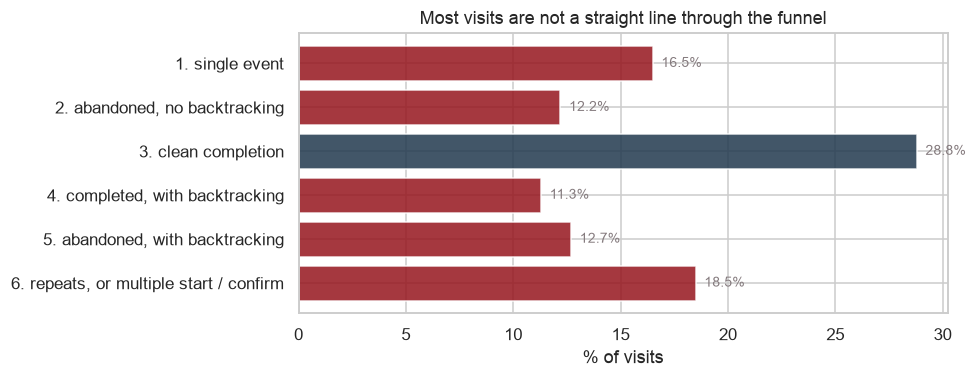

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))

colours = [NAVY if p.startswith("3") else MAROON for p in shape.index]
ax.barh(shape.index, shape["%"], color=colours, alpha=.85)
ax.invert_yaxis()
ax.set_xlabel("% of visits")
ax.set_title("Most visits are not a straight line through the funnel", fontsize=12)

for i, pct in enumerate(shape["%"]):
    ax.text(pct + 0.4, i, f"{pct}%", va="center", fontsize=9, color=GREY)

fig.tight_layout()
plt.show()

## 2. Reading real visits

One representative visit per pattern, shown as the ordered sequence of events.
These are the cases every reconstruction rule has to handle.

In [5]:
RNG = np.random.default_rng(7)   # fixed, so the same visits appear on every run


def pick(pattern, n=1):
    """Take a mid-sized example of a pattern — not the smallest or the freakiest."""
    candidates = visits[visits.pattern == pattern]
    typical = candidates[
        candidates.events.between(
            candidates.events.quantile(.25), candidates.events.quantile(.75)
        )
    ]
    pool = typical if len(typical) else candidates
    return RNG.choice(pool.index.to_numpy(), size=n, replace=False)


def show(visit_id):
    v = events[events.visit_id == visit_id].sort_values("date_time")
    elapsed = (v.date_time - v.date_time.iloc[0]).dt.total_seconds()
    out = v[["process_step", "date_time"]].copy()
    out["seconds in"] = elapsed.astype(int).values
    out["step"] = v.step_rank.values
    return out.reset_index(drop=True)


samples = {p: pick(p)[0] for p in shape.index}
samples

{'1. single event': '95109724_51703446157_204185',
 '2. abandoned, no backtracking': '665583979_53034637804_581605',
 '3. clean completion': '713963875_50922808107_535200',
 '4. completed, with backtracking': '903036257_55140458561_116208',
 '5. abandoned, with backtracking': '616719426_37256103158_532036',
 '6. repeats, or multiple start / confirm': '795940878_15208263422_10482'}

In [6]:
for pattern, visit_id in samples.items():
    v = visits.loc[visit_id]
    print(f"\n{'=' * 62}\n{pattern}   —   visit {visit_id}")
    print(f"group: {v.group}   events: {v.events}   "
          f"duration: {v.seconds:.0f}s   reached confirm: {v.reached_confirm}")
    print(show(visit_id).to_string(index=False))


1. single event   —   visit 95109724_51703446157_204185
group: Control   events: 1   duration: 0s   reached confirm: False
process_step           date_time  seconds in  step
       start 2017-06-19 11:50:33           0     0

2. abandoned, no backtracking   —   visit 665583979_53034637804_581605
group: Test   events: 2   duration: 12s   reached confirm: False
process_step           date_time  seconds in  step
       start 2017-04-02 08:15:49           0     0
      step_1 2017-04-02 08:16:01          12     1

3. clean completion   —   visit 713963875_50922808107_535200
group: Control   events: 5   duration: 193s   reached confirm: True
process_step           date_time  seconds in  step
       start 2017-04-10 09:56:42           0     0
      step_1 2017-04-10 09:57:04          22     1
      step_2 2017-04-10 09:57:23          41     2
      step_3 2017-04-10 09:59:10         148     3
     confirm 2017-04-10 09:59:55         193     4

4. completed, with backtracking   —   visit 903

### The same visits, drawn

Position in the funnel against time makes the shape of each journey visible at
a glance: a straight climb is a clean completion, a dip is backtracking, a flat
run is a repeated step.

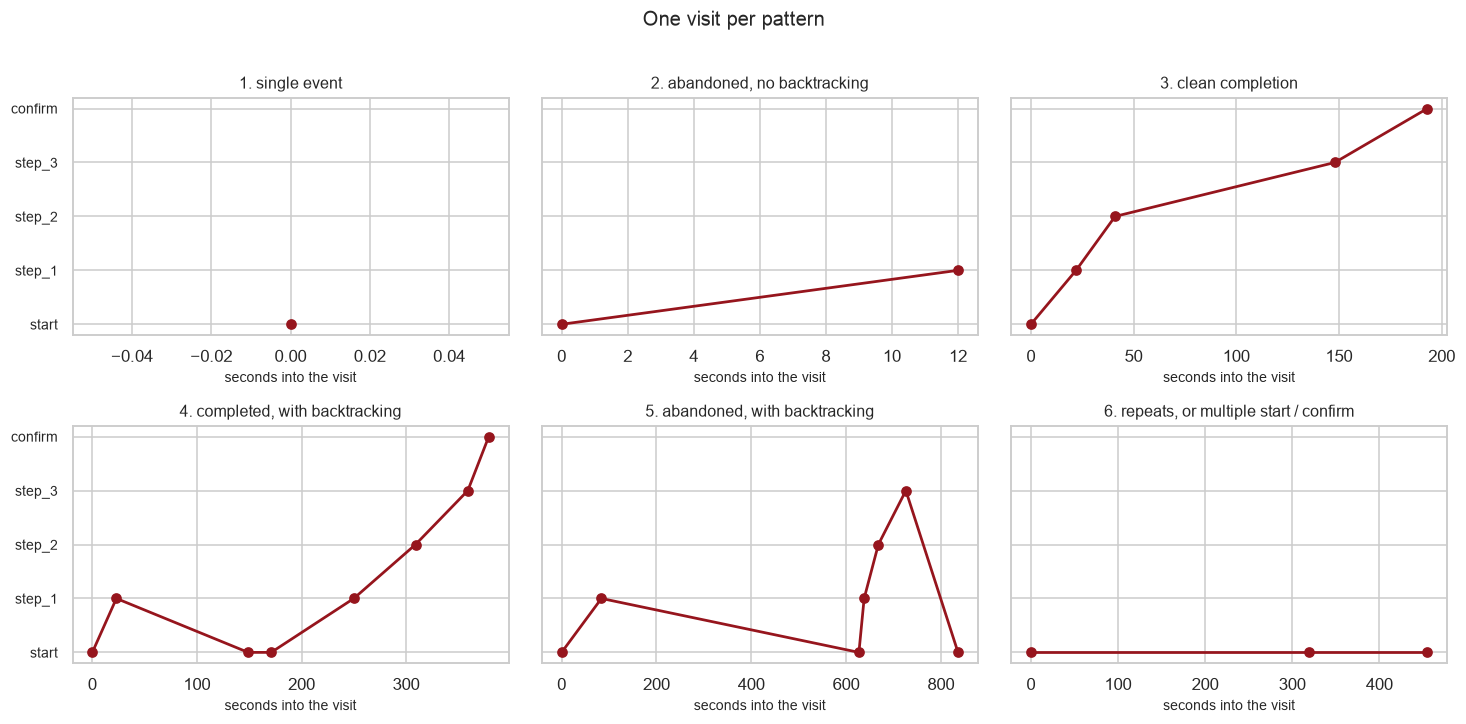

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.5), sharey=True)

for ax, (pattern, visit_id) in zip(axes.flat, samples.items()):
    v = events[events.visit_id == visit_id].sort_values("date_time")
    elapsed = (v.date_time - v.date_time.iloc[0]).dt.total_seconds()

    ax.plot(elapsed, v.step_rank, marker="o", color=MAROON, linewidth=1.8, markersize=6)
    ax.set_title(pattern, fontsize=10.5)
    ax.set_yticks(range(len(FUNNEL)))
    ax.set_yticklabels(FUNNEL, fontsize=9)
    ax.set_xlabel("seconds into the visit", fontsize=9)

fig.suptitle("One visit per pattern", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### A closer look at the awkward cases

Multiple `start` events affect a third of all visits, so how they are read
changes almost every KPI. Below are several examples together.

In [8]:
multi_start = visits[visits.starts > 1]
print(f"{len(multi_start):,} visits with more than one start "
      f"({len(multi_start) / len(visits):.1%} of visits)")
print()
print(multi_start.starts.value_counts().sort_index().head(6).to_frame("visits").to_string())

20,718 visits with more than one start (29.9% of visits)

        visits
starts        
2        12249
3         4553
4         2066
5          903
6          427
7          230


In [9]:
for visit_id in pick("6. repeats, or multiple start / confirm", n=2):
    v = visits.loc[visit_id]
    print(f"\n{'=' * 62}\nvisit {visit_id}   starts: {v.starts}   "
          f"confirms: {v.confirms}   duration: {v.seconds:.0f}s")
    print(show(visit_id).to_string(index=False))


visit 304487409_9262724110_581947   starts: 4   confirms: 0   duration: 2897s
process_step           date_time  seconds in  step
       start 2017-05-21 18:46:41           0     0
       start 2017-05-21 19:02:46         965     0
       start 2017-05-21 19:18:53        1932     0
       start 2017-05-21 19:34:58        2897     0

visit 852093727_73166941184_671165   starts: 1   confirms: 2   duration: 167s
process_step           date_time  seconds in  step
       start 2017-04-13 11:13:28           0     0
      step_1 2017-04-13 11:13:36           8     1
      step_2 2017-04-13 11:14:14          46     2
      step_3 2017-04-13 11:14:38          70     3
     confirm 2017-04-13 11:15:25         117     4
     confirm 2017-04-13 11:16:15         167     4


Day 1 flagged 2,538 visits in the raw log where several different steps shared
a single timestamp — events that cannot be ordered by time at all. Worth
checking whether they survived the cleaning.

In [10]:
same_second = visits[(visits.seconds == 0) & (visits.events > 1)]
print(f"visits where every event shares one timestamp: {len(same_second):,}")

if len(same_second):
    example = same_second.index[0]
    print(f"\nexample — visit {example}")
    print(show(example).to_string(index=False))
else:
    print("\nNone remain. Removing the exact duplicates accounted for all of them,")
    print("so this is no longer a decision we have to make.")

visits where every event shares one timestamp: 0

None remain. Removing the exact duplicates accounted for all of them,
so this is no longer a decision we have to make.


In [11]:
# Visits that still have no measurable duration are the single-event ones
no_duration = visits[visits.seconds == 0]

print(f"visits lasting zero seconds: {len(no_duration):,} "
      f"({len(no_duration) / len(visits):.1%} of visits)")
print()
print(no_duration.events.value_counts().sort_index().to_frame("visits").to_string())

visits lasting zero seconds: 11,383 (16.5% of visits)

        visits
events        
1        11383


## 3. How often does each awkward case occur?

Frequency decides how much any given rule actually matters.

In [12]:
prevalence = pd.DataFrame([
    {"case": "More than one start", "visits": (visits.starts > 1).sum()},
    {"case": "More than one confirm", "visits": (visits.confirms > 1).sum()},
    {"case": "No start at all", "visits": (visits.starts == 0).sum()},
    {"case": "At least one repeated step", "visits": (visits.repeats > 0).sum()},
    {"case": "At least one backward move", "visits": (visits.backsteps > 0).sum()},
    {"case": "Single event only", "visits": (visits.events == 1).sum()},
    {"case": "No measurable duration", "visits": (visits.seconds == 0).sum()},
    {"case": "Longer than one hour", "visits": (visits.seconds > 3600).sum()},
])
prevalence["% of visits"] = (prevalence.visits / len(visits) * 100).round(1)
prevalence.sort_values("visits", ascending=False, ignore_index=True)

,case,visits,% of visits
0,More than one start,20718,29.9
1,At least one repeated step,18829,27.2
2,At least one backward move,16613,24.0
3,Single event only,11383,16.5
4,No measurable duration,11383,16.5
5,No start at all,5252,7.6
6,More than one confirm,3713,5.4
7,Longer than one hour,258,0.4


### How far back do people go?

Whether a backward move counts as an error may depend on how far back it goes.
Returning one step is not obviously the same act as returning to the start.

In [13]:
back = events[events.is_backward]

distance = back.steps_back.value_counts().sort_index().to_frame("events")
distance["%"] = (distance.events / distance.events.sum() * 100).round(1)
distance.index.name = "steps back"
distance

,events,%
steps back,,
1.0,18200,69.9
2.0,3459,13.3
3.0,3447,13.2
4.0,927,3.6


### Do clients come back across visits?

If the same client makes several attempts, measuring per visit and measuring
per client give different answers.

In [14]:
per_client = visits.groupby("client_id").agg(
    visits=("events", "size"),
    ever_completed=("reached_confirm", "any"),
    completed_visits=("reached_confirm", "sum"),
)

print(per_client.visits.value_counts().sort_index().head(6).to_frame("clients").to_string())
print()
print(f"clients with more than one visit: {(per_client.visits > 1).sum():,} "
      f"({(per_client.visits > 1).mean():.1%})")
print()
print("completion rate measured per visit:  "
      f"{visits.reached_confirm.mean():.1%}")
print("completion rate measured per client: "
      f"{per_client.ever_completed.mean():.1%}")

        clients
visits         
1         37336
2          9418
3          2308
4           712
5           261
6           105

clients with more than one visit: 12,957 (25.8%)

completion rate measured per visit:  54.4%
completion rate measured per client: 67.4%


Those last two numbers answer different questions and neither is wrong. Which
one belongs in the report is a decision, not a calculation.

## The reconstruction rules

Six decisions, each taken from the evidence above rather than in the abstract.
They apply to every journey without exception, and they are fixed before any
KPI is computed.

### 1. A visit is one journey, and its first `start` opens it

Nearly 30% of visits contain more than one `start`. We treat the visit as a
single attempt and take the earliest `start` as its beginning.

The brief's own instruction is to begin by treating each visit as a candidate
journey, and a restart inside one session is more plausibly a person retrying
than a person opening a second, independent application. Counting each
`start` as a separate attempt would inflate the denominator of every rate with
events that were never distinct journeys.

### 2. The first `confirm` closes it

3,713 visits record more than one `confirm`. Only the first counts.
Confirming twice is not completing twice, and the later ones fall after the
outcome we are measuring has already happened.

### 3. The client is the unit of analysis; the visit is reported alongside

This is the decision with the largest consequence. The same data gives a
completion rate of **54.4% per visit** and **67.4% per client** — thirteen
points apart, with 25.8% of clients returning across more than one visit.

Primary KPIs are computed per client, because **the experiment randomised
clients, not visits**. Analysing at visit level would break that: a client who
returned five times would carry five times the weight of one who succeeded
immediately, and the balance the randomisation guarantees would no longer
hold. Visit-level figures are reported as a secondary view, since they
describe the experience of a single session.

### 4. Completing means reaching `confirm`

At client level, a client completed if **any** of their visits reached
`confirm`. That matches the business outcome: the process was finished, and a
first failed attempt does not undo a later success.

### 5. Visits with no measurable duration stay in rates, but not in times

11,383 visits (16.5%) last zero seconds, and all of them contain a single
event. They remain in the denominator of completion and funnel rates —
leaving immediately is a real outcome, not missing data — but are excluded
from Completion Time and Effective Time, where there is simply nothing to
measure.

The related problem Day 1 flagged, visits whose events all share one
timestamp, no longer exists: removing the exact duplicates accounted for all
of them.

### 6. Backward movement is measured, not assumed to be an error

24% of visits contain at least one backward move. We **do not** treat
backtracking as an error by default. Instead:

- **Step Backs** counts backward movements directly, as a descriptive measure
  of navigation behaviour.
- **Error Rate** is defined as repeated steps within a journey — a client
  redoing the same step suggests something did not take, which is closer to
  friction than deliberate movement is.

The reason is that going back is ambiguous. Reviewing an earlier choice before
committing is careful behaviour, not confusion, and an interface that makes
review easy would be penalised by a metric that cannot tell the two apart.
Returning one step is also not obviously the same act as returning to the
start, and the distribution above shows both happen.

Because this choice could reasonably have gone the other way, we **report both
definitions** and check whether the conclusion survives either. If it does,
the recommendation does not rest on this assumption. If it does not, that is
itself the most important finding of the analysis, and it has to be stated
rather than hidden behind whichever definition we happened to pick.

### Reproducibility

These six rules are applied to every journey without exception, and no rule
changes once KPIs are being computed. Any later revision means recomputing
everything downstream, not adjusting one metric.

**Final question:** could another analyst read these rules and reproduce every
journey exactly as we did?